# 02 — Получение текстов заголовков из URL

Датасет UCI не содержит текст заголовка — только его числовые статистики. Здесь восстанавливаем сам заголовок тремя путями:

1. **slug-парсинг URL** (детерминированно, 100% покрытие, всегда доступно).
2. **HTTP** (опционально): живая страница Mashable — `og:title` / `<title>`.
3. **Wayback Machine** (опционально): для 404 из архива.

В CI и `make run-all` используется только slug-режим (offline и детерминированный). HTTP/Wayback-режимы опциональны и запускаются вручную: `make parse` по умолчанию отрабатывает slug.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import RAW_CSV_PATH, REPORT_IMAGES_DIR, TITLES_JSONL_PATH, ensure_directories
from src.data.parse_titles import extract_title_from_slug, parse_titles
from src.utils.seed import set_global_seed

set_global_seed(); ensure_directories()

In [2]:
sample_urls = [
    'http://mashable.com/2013/01/07/amazon-instant-video-browser/',
    'http://mashable.com/2014/10/31/apple-pay-launch/',
    'http://mashable.com/2014/07/04/american-flag-emoji/',
]
for u in sample_urls:
    print(f'{u}\n  -> {extract_title_from_slug(u)!r}')

http://mashable.com/2013/01/07/amazon-instant-video-browser/
  -> 'Amazon Instant Video Browser'
http://mashable.com/2014/10/31/apple-pay-launch/
  -> 'Apple Pay Launch'
http://mashable.com/2014/07/04/american-flag-emoji/
  -> 'American Flag Emoji'


In [3]:
titles_df = parse_titles(input_csv=RAW_CSV_PATH, output_jsonl=TITLES_JSONL_PATH, mode='slug')
titles_df.head(5)

2026-05-11 16:41:03,019 INFO src.data.parse_titles :: Всего URL: 39644 | Из кэша: 39644 | К обработке: 0 | Режим: slug


парсинг заголовков: 0it [00:00, ?it/s]

парсинг заголовков: 0it [00:00, ?it/s]

2026-05-11 16:41:03,300 INFO src.data.parse_titles :: Покрытие: {'slug': '100.0%', 'http': '0.0%', 'wayback': '0.0%', 'final_non_empty': '100.0%'}


,url,title_slug,title_http,title_wayback,title_source,title
0,http://mashable.com/2013/01/07/amazon-instant-...,Amazon Instant Video Browser,None,None,slug,Amazon Instant Video Browser
1,http://mashable.com/2013/01/07/ap-samsung-spon...,Ap Samsung Sponsored Tweets,None,None,slug,Ap Samsung Sponsored Tweets
2,http://mashable.com/2013/01/07/apple-40-billio...,Apple 40 Billion App Downloads,None,None,slug,Apple 40 Billion App Downloads
3,http://mashable.com/2013/01/07/astronaut-notre...,Astronaut Notre Dame Bcs,None,None,slug,Astronaut Notre Dame Bcs
4,http://mashable.com/2013/01/07/att-u-verse-apps/,Att U Verse Apps,None,None,slug,Att U Verse Apps


In [4]:
coverage = {
    'slug_non_empty': (titles_df['title_slug'].str.len() > 0).mean(),
    'http_non_null': titles_df['title_http'].notna().mean(),
    'wayback_non_null': titles_df['title_wayback'].notna().mean(),
    'final_non_empty': (titles_df['title'].str.len() > 0).mean(),
}
print('Coverage:')
for k, v in coverage.items():
    print(f'  {k}: {v:.2%}')
print()
print('Source distribution:')
print(titles_df['title_source'].value_counts())

Coverage:
  slug_non_empty: 100.00%
  http_non_null: 0.00%
  wayback_non_null: 0.00%
  final_non_empty: 100.00%

Source distribution:
title_source
slug    39644
Name: count, dtype: int64


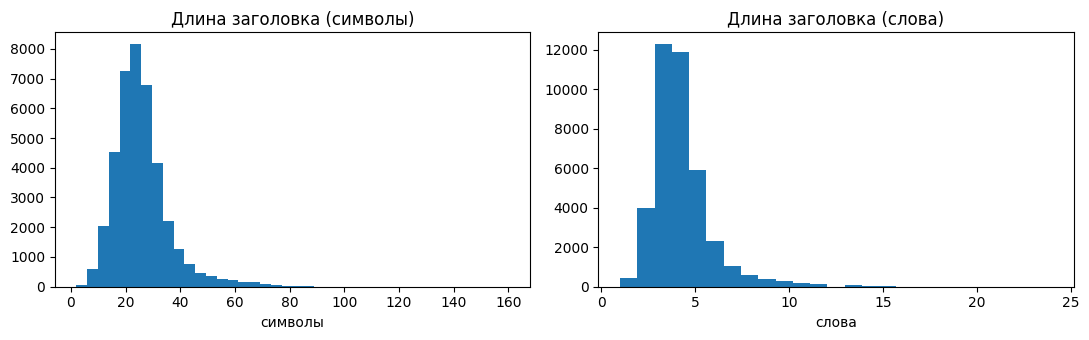

In [5]:
titles_df['title_len_chars'] = titles_df['title'].str.len()
titles_df['title_len_words'] = titles_df['title'].str.split().map(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(titles_df['title_len_chars'], bins=40)
axes[0].set_title('Длина заголовка (символы)'); axes[0].set_xlabel('символы')
axes[1].hist(titles_df['title_len_words'], bins=25)
axes[1].set_title('Длина заголовка (слова)'); axes[1].set_xlabel('слова')
plt.tight_layout()
plt.savefig(REPORT_IMAGES_DIR / '02_title_length_distribution.png', bbox_inches='tight')
plt.show()

In [6]:
df_raw = pd.read_csv(RAW_CSV_PATH)
df_raw.columns = [c.strip() for c in df_raw.columns]
joined = titles_df.merge(df_raw[['url', 'shares']], on='url', how='inner')
print('Top-10 most-shared titles:')
print(joined.sort_values('shares', ascending=False).head(10)[['title', 'shares']].to_string(index=False))
print()
print('Bottom-10 least-shared titles:')
print(joined.sort_values('shares').head(10)[['title', 'shares']].to_string(index=False))

Top-10 most-shared titles:
                              title  shares
                    Low Cost Iphone  843300
            Dove Ad Beauty Sketches  690400
First 100 Gilt Soundcloud Stitchfix  663600
         Kanye West Harvard Lecture  652900
                  Wealth Inequality  617900
                  Roomba 880 Review  441000
          Australia Heatwave Photos  310800
               Blackberry 1 Million  306100
                   Ibm Watson Brief  298400
        Ebola Cdc Active Monitoring  284700

Bottom-10 least-shared titles:
                                          title  shares
                            Wand Remote Control       1
               Troll Appreciation Day Tickets 2       4
                                Mad Max Trailer       5
                               Nokia Lumia 1020       8
Lying Down For Jobs During The Great Depression      22
                     Titanic Replica Theme Park      22
                  Tablets Education Competition      23
         

### Выводы (02_parse_titles)

* Slug-парсинг даёт 100% покрытие и служит надёжным фолбэком. Тексты заголовков близки к оригинальным: Mashable использует slug = kebab-case заголовок.
* HTTP/Wayback-обогащение запускается опционально (`python -m src.data.parse_titles --mode full --workers 8`) и полезно для дополнительной проверки; slug-версии достаточно для feature engineering.
* Кэш результатов в `data/raw/titles.jsonl` позволяет продолжать парсинг после прерывания.